## CNN - Simple Architecture

In [1]:
import os
import pandas as pd
import numpy as np
import time

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt

from torchvision import models
from torchinfo import summary
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader, Dataset
from torchmetrics.classification import MulticlassConfusionMatrix, MulticlassPrecision, MulticlassRecall, MulticlassF1Score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report 

### Checking if Gpu were recognized

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("PyTorch is using GPU!")
    print(torch.cuda.get_device_name(0)) #prints the name of the GPU.
else:
    device = torch.device("cpu")
    print("PyTorch is using CPU.")

PyTorch is using GPU!
NVIDIA GeForce RTX 3050 Ti Laptop GPU


# Loading Dataset

### Training dataset

In [3]:
os.path.realpath('data/p2-mammography')

'/home/viviane/projects/breast-cancer-v2/notebooks/data/p2-mammography'

In [4]:
path = os.path.realpath('data/p2-mammography')
list_path = path.split('/')
list_path.remove('breast-cancer-v2')
list_path.remove('notebooks')
path_train = os.path.join('/'.join(list_path), 'train_augmented')
path_train

'/home/viviane/projects/data/p2-mammography/train_augmented'

In [5]:
dataset = datasets.ImageFolder(
    root=path_train, 
    transform=transforms.ToTensor()
)
classes = dataset.classes
print(classes)

['Density1_Benign', 'Density1_Malignant', 'Density2_Benign', 'Density2_Malignant', 'Density3_Benign', 'Density3_Malignant', 'Density4_Benign', 'Density4_Malignant']


### Test dataset

In [6]:
path = os.path.realpath('data/p2-mammography')
list_path = path.split('/')
list_path.remove('breast-cancer-v2')
list_path.remove('notebooks')
path_test = os.path.join('/'.join(list_path), 'test_augmented')
path_test

'/home/viviane/projects/data/p2-mammography/test_augmented'

In [7]:
train_dir = path_train
val_dir = path_test

# Preprocessing

In [8]:
IMAGE_SIZE = 224
BATCH_SIZE = 16

In [9]:
# Define data augmentation for the training dataset
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),                      
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Normalization
])

# Define validation dataset - no augmentation, only resizing and normalization
test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


# split train_dataset and load
train_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_dataset = torchvision.datasets.ImageFolder(root=val_dir, transform=test_transforms)

train_size = int(0.8 * len(train_dataset))  # 80% for training
val_size = len(train_dataset) - train_size  # Remaining for testing

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Define loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)


print(f'Training samples: {len(train_dataset)}, , Validation samples: {len(val_dataset)}, Test samples: {len(test_dataset)}')

Training samples: 7818, , Validation samples: 1955, Test samples: 1957


# Architecture

In [10]:
class BCCNN(nn.Module):
    def __init__(self, num_classes):
        super(BCCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(128 * (IMAGE_SIZE // 8) * (IMAGE_SIZE // 8), 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten the tensor
        x = x.view(x.size(0), -1) 
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 8

model = BCCNN(num_classes=num_classes).to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

BCCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=8, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [12]:
summary(model, input_size=(BATCH_SIZE, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
BCCNN                                    [16, 8]                   --
├─Conv2d: 1-1                            [16, 32, 224, 224]        896
├─MaxPool2d: 1-2                         [16, 32, 112, 112]        --
├─Conv2d: 1-3                            [16, 64, 112, 112]        18,496
├─MaxPool2d: 1-4                         [16, 64, 56, 56]          --
├─Conv2d: 1-5                            [16, 128, 56, 56]         73,856
├─MaxPool2d: 1-6                         [16, 128, 28, 28]         --
├─Linear: 1-7                            [16, 512]                 51,380,736
├─Dropout: 1-8                           [16, 512]                 --
├─Linear: 1-9                            [16, 8]                   4,104
Total params: 51,478,088
Trainable params: 51,478,088
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 8.96
Input size (MB): 9.63
Forward/backward pass size (MB): 359.73
Params size (MB): 205.91


# Trainning

In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    # Metrics
    confusion_matrix = MulticlassConfusionMatrix(num_classes=8)
    precision = MulticlassPrecision(num_classes=10, average='macro')
    recall = MulticlassRecall(num_classes=10, average='macro')
    f1_score = MulticlassF1Score(num_classes=10, average='macro')

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Clear gradients
            optimizer.zero_grad()

            # feed foward
            outputs = model(inputs)
            
            # Compute loss using cross entropy
            loss = criterion(outputs, labels)

            # backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            # Update results
            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (preds == labels).sum().item()

        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(100 * correct_train / total_train)

        # Evaluation part to print metrics for each epoch
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (preds == labels).sum().item()

                # For metrics
                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(100 * correct_val / total_val)

        
        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)

        
        precision_value = precision(all_preds, all_labels)
        recall_value = recall(all_preds, all_labels)
        f1_value = f1_score(all_preds, all_labels)
        conf_matrix = confusion_matrix(all_preds, all_labels)

        
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print(f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accuracies[-1]:.2f}%")
        print(f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accuracies[-1]:.2f}%")
        print(f"Precision: {precision_value:.4f} | Recall: {recall_value:.4f} | F1 Score: {f1_value:.4f}\n")

    return train_losses, val_losses, train_accuracies, val_accuracies, conf_matrix

In [14]:
t1 = time.time()
print(f"Using device: {device}")

train_losses, val_losses, train_accuracies, val_accuracies, conf_matrix = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs=50)

print("######## Training Finished in {} seconds ###########".format(time.time()-t1))

Using device: cuda
Epoch 1/50
Train Loss: 2.0468 | Train Acc: 17.10%
Val Loss: 1.9045 | Val Acc: 23.32%
Precision: 0.2288 | Recall: 0.2387 | F1 Score: 0.1949

Epoch 2/50
Train Loss: 1.7788 | Train Acc: 29.06%
Val Loss: 1.6435 | Val Acc: 33.15%
Precision: 0.3398 | Recall: 0.3354 | F1 Score: 0.3141

Epoch 3/50
Train Loss: 1.5134 | Train Acc: 41.57%
Val Loss: 1.4696 | Val Acc: 41.74%
Precision: 0.4120 | Recall: 0.4195 | F1 Score: 0.4120

Epoch 4/50
Train Loss: 1.2450 | Train Acc: 52.70%
Val Loss: 1.4215 | Val Acc: 45.01%
Precision: 0.4403 | Recall: 0.4536 | F1 Score: 0.4396

Epoch 5/50
Train Loss: 0.9876 | Train Acc: 63.70%
Val Loss: 1.4012 | Val Acc: 49.16%
Precision: 0.4798 | Recall: 0.4942 | F1 Score: 0.4817

Epoch 6/50
Train Loss: 0.7230 | Train Acc: 73.82%
Val Loss: 1.5625 | Val Acc: 48.75%
Precision: 0.4944 | Recall: 0.4886 | F1 Score: 0.4820

Epoch 7/50
Train Loss: 0.5217 | Train Acc: 81.68%
Val Loss: 1.6635 | Val Acc: 48.44%
Precision: 0.4803 | Recall: 0.4873 | F1 Score: 0.4812

E

# Evaluating

In [22]:
model.eval() 

with torch.no_grad(): 
    correct = 0
    total = 0
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Test Accuracy of the model on the {total} test images: {(correct / total) * 100:.2f}%')

Test Accuracy of the model on the 1957 test images: 30.15%


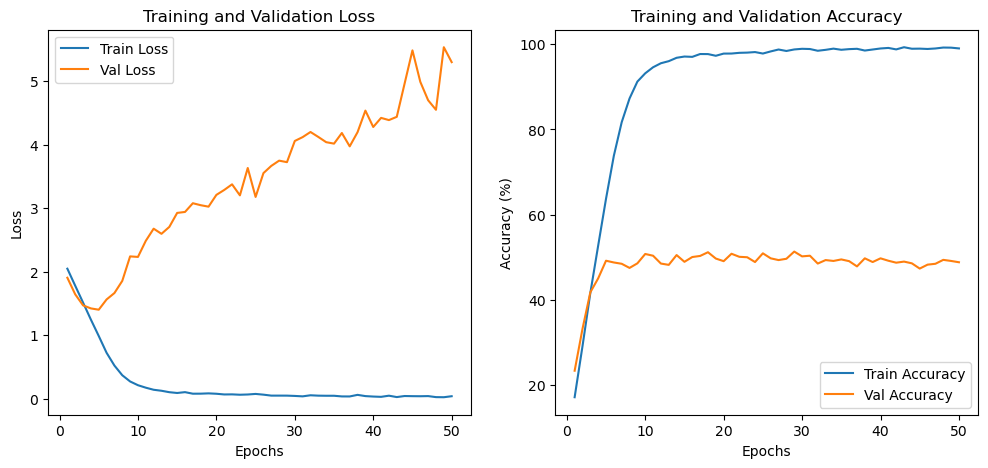

In [20]:
def plot_training(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy')
    plt.plot(epochs, val_accuracies, label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.show()

plot_training(train_losses, val_losses, train_accuracies, val_accuracies)

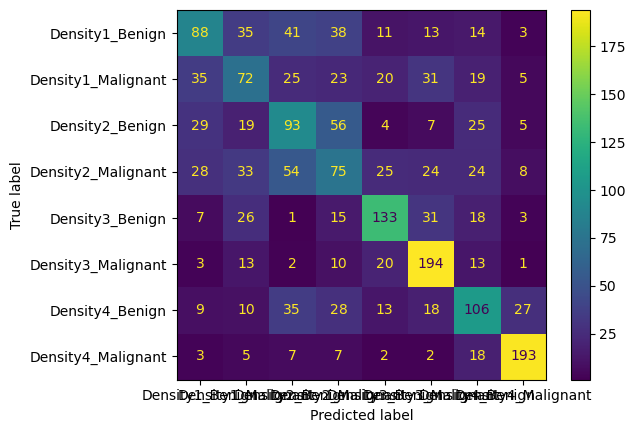

In [21]:
cm = conf_matrix.cpu().numpy()
disp = ConfusionMatrixDisplay(cm, display_labels=classes,)
disp.plot()

# Metrics

In [24]:
precision = MulticlassPrecision(num_classes=num_classes, average=None)
recall = MulticlassRecall(num_classes=num_classes, average=None)
f1_score = MulticlassF1Score(num_classes=num_classes, average=None)


all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())


all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)


per_class_precision = precision(all_preds, all_labels)
per_class_recall = recall(all_preds, all_labels)
per_class_f1 = f1_score(all_preds, all_labels)


for i, name in enumerate(classes):
    print(f"Class {i}-{name}: Precision: {per_class_precision[i]:.2f}, Recall: {per_class_recall[i]:.2f}, F1-Score: {per_class_f1[i]:.2f}")

Class 0-Density1_Benign: Precision: 0.44, Recall: 0.36, F1-Score: 0.40
Class 1-Density1_Malignant: Precision: 0.34, Recall: 0.31, F1-Score: 0.33
Class 2-Density2_Benign: Precision: 0.36, Recall: 0.39, F1-Score: 0.38
Class 3-Density2_Malignant: Precision: 0.30, Recall: 0.28, F1-Score: 0.29
Class 4-Density3_Benign: Precision: 0.58, Recall: 0.57, F1-Score: 0.58
Class 5-Density3_Malignant: Precision: 0.61, Recall: 0.76, F1-Score: 0.67
Class 6-Density4_Benign: Precision: 0.45, Recall: 0.43, F1-Score: 0.44
Class 7-Density4_Malignant: Precision: 0.79, Recall: 0.81, F1-Score: 0.80


# Save Model

In [23]:
# torch.save(model.state_dict(), '/home/viviane/projects/breast-cancer-v2/models/model_shufflenet.pt')